# Raw Data Analysis - Meteorological Station Data

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

METEO_STATION_RAW_PATH = "../data/bronze/meteo_station_raw.csv"

In [ ]:
def load_csv(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()

    if not lines:
        return pd.DataFrame()

    # 1. Get header and count target columns
    header = lines[0].strip().split(',')
    num_cols = len(header)
    
    # 2. Find where the JSON is (it's always the column before the last 4)
    # The last 4 are always: ingestion_timestamp, source, processing_status, error_message
    json_idx = header.index('raw_json')
    cols_after_json = num_cols - (json_idx + 1)

    data_rows = []
    for line in lines[1:]:
        line = line.strip()
        if not line:
            continue
        
        parts = line.split(',')
        
        # Leading columns (before JSON)
        leading = parts[:json_idx]
        
        # Trailing columns - take exactly the last cols_after_json columns
        trailing = parts[-cols_after_json:]

        # Everything in between is the JSON
        json_parts = parts[json_idx:-cols_after_json]
        json_blob = ",".join(json_parts).strip('"')

        # Combine and ensure we only have the exact number of columns as the header
        full_row = leading + [json_blob] + trailing
        data_rows.append(full_row[:num_cols])

    # Drop columns that are entirely empty or whitespace-only like 'error_message'
    df = pd.DataFrame(data_rows, columns=header)
    df = df.replace(r"^\s*$", pd.NA, regex=True)
    df = df.dropna(axis=1, how='all')

    return df

## Load data and check general properties

In [2]:
meteo_station_raw = load_csv(METEO_STATION_RAW_PATH)
meteo_station_raw.head()

,id,plant_id,timestamp,amb_temp_c,module_temp_c,wind_speed_ms,wind_dir_deg,humidity_percent,poa_irradiance_wm2,raw_json,ingestion_timestamp,source,processing_status
0,45,d8164055-4101-4443-9540-74249ee8a9bc,2026-02-01 20:13:12.925557+00,9.35,9.35,2.00,151.80,53.00,0.00,"{'""guid'"": '""d8164055-4101-4443-9540-74249ee8a...",2026-02-01 19:41:46.373891+00,kafka,processed
1,295,d8164055-4101-4443-9540-74249ee8a9bc,2026-02-01 23:19:08.060787+00,3.52,3.52,0.93,170.40,58.10,0.00,"{'""guid'"": '""d8164055-4101-4443-9540-74249ee8a...",2026-02-01 19:44:57.396026+00,kafka,processed
2,123,d8164055-4101-4443-9540-74249ee8a9bc,2026-02-01 21:10:55.375119+00,7.60,7.60,1.53,184.30,56.60,0.00,"{'""guid'"": '""d8164055-4101-4443-9540-74249ee8a...",2026-02-01 19:42:46.042152+00,kafka,processed
3,124,d8164055-4101-4443-9540-74249ee8a9bc,2026-02-01 21:11:33.179223+00,7.18,7.18,1.63,185.00,56.80,0.00,"{'""guid'"": '""d8164055-4101-4443-9540-74249ee8a...",2026-02-01 19:42:46.063847+00,kafka,processed
4,1,d8164055-4101-4443-9540-74249ee8a9bc,2026-02-01 19:41:11.671261+00,9.97,9.97,2.22,127.90,54.70,0.00,"{'""guid'"": '""d8164055-4101-4443-9540-74249ee8a...",2026-02-01 19:41:13.542297+00,kafka,processed


In [3]:
meteo_station_raw.shape

(128171, 13)

In [4]:
meteo_station_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 128171 entries, 0 to 128170
Data columns (total 13 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   id                   128171 non-null  str  
 1   plant_id             128171 non-null  str  
 2   timestamp            128171 non-null  str  
 3   amb_temp_c           128171 non-null  str  
 4   module_temp_c        128171 non-null  str  
 5   wind_speed_ms        128171 non-null  str  
 6   wind_dir_deg         128171 non-null  str  
 7   humidity_percent     128171 non-null  str  
 8   poa_irradiance_wm2   128171 non-null  str  
 9   raw_json             128171 non-null  str  
 10  ingestion_timestamp  128171 non-null  str  
 11  source               128171 non-null  str  
 12  processing_status    128171 non-null  str  
dtypes: str(13)
memory usage: 61.1 MB


Convert variables to the indicated types.

In [5]:
# id -> integer
# plant_id -> uuid
# timestamp -> datetime
# amb_temp_c -> float
# module_temp_c -> float
# wind_speed_ms -> float
# wind_dir_deg -> float
# humidity_percent -> float
# poa_irradiance_wm2 -> float
# raw_json -> json
# ingestion_timestamp -> datetime
# source -> string
# processing_status -> string

meteo_station_raw["id"] = meteo_station_raw["id"].astype(int)
meteo_station_raw["timestamp"] = pd.to_datetime(meteo_station_raw["timestamp"], format='ISO8601')
meteo_station_raw["amb_temp_c"] = meteo_station_raw["amb_temp_c"].astype(float)
meteo_station_raw["module_temp_c"] = meteo_station_raw["module_temp_c"].astype(float)
meteo_station_raw["wind_speed_ms"] = meteo_station_raw["wind_speed_ms"].astype(float)
meteo_station_raw["wind_dir_deg"] = meteo_station_raw["wind_dir_deg"].astype(float)
meteo_station_raw["humidity_percent"] = meteo_station_raw["humidity_percent"].astype(float)
meteo_station_raw["poa_irradiance_wm2"] = meteo_station_raw["poa_irradiance_wm2"].astype(float)
meteo_station_raw["ingestion_timestamp"] = pd.to_datetime(meteo_station_raw["ingestion_timestamp"], format='ISO8601')

In [6]:
meteo_station_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 128171 entries, 0 to 128170
Data columns (total 13 columns):
 #   Column               Non-Null Count   Dtype              
---  ------               --------------   -----              
 0   id                   128171 non-null  int64              
 1   plant_id             128171 non-null  str                
 2   timestamp            128171 non-null  datetime64[us, UTC]
 3   amb_temp_c           128171 non-null  float64            
 4   module_temp_c        128171 non-null  float64            
 5   wind_speed_ms        128171 non-null  float64            
 6   wind_dir_deg         128171 non-null  float64            
 7   humidity_percent     128171 non-null  float64            
 8   poa_irradiance_wm2   128171 non-null  float64            
 9   raw_json             128171 non-null  str                
 10  ingestion_timestamp  128171 non-null  datetime64[us, UTC]
 11  source               128171 non-null  str                
 12  processing_st

Order the data by timestamp.

In [7]:
# Order by timestamp
# "id" field indicates the order of insertion in db, but it is not guaranteed to be in order of timestamp, so we sort by timestamp to be sure.
meteo_station_raw = meteo_station_raw.sort_values("timestamp").reset_index(drop=True)
meteo_station_raw

,id,plant_id,timestamp,amb_temp_c,module_temp_c,wind_speed_ms,wind_dir_deg,humidity_percent,poa_irradiance_wm2,raw_json,ingestion_timestamp,source,processing_status
0,1,d8164055-4101-4443-9540-74249ee8a9bc,2026-02-01 19:41:11.671261+00:00,9.97,9.97,2.22,127.9,54.7,0.0,"{'""guid'"": '""d8164055-4101-4443-9540-74249ee8a...",2026-02-01 19:41:13.542297+00:00,kafka,processed
1,2,d8164055-4101-4443-9540-74249ee8a9bc,2026-02-01 19:41:45.845070+00:00,10.68,10.68,2.14,126.4,55.0,0.0,"{'""guid'"": '""d8164055-4101-4443-9540-74249ee8a...",2026-02-01 19:41:13.625846+00:00,kafka,processed
2,3,d8164055-4101-4443-9540-74249ee8a9bc,2026-02-01 19:42:28.589549+00:00,10.02,10.02,2.19,125.5,54.4,0.0,"{'""guid'"": '""d8164055-4101-4443-9540-74249ee8a...",2026-02-01 19:41:13.663146+00:00,kafka,processed
3,4,d8164055-4101-4443-9540-74249ee8a9bc,2026-02-01 19:43:10.581197+00:00,10.03,10.03,2.19,129.0,53.8,0.0,"{'""guid'"": '""d8164055-4101-4443-9540-74249ee8a...",2026-02-01 19:41:15.562114+00:00,kafka,processed
4,5,d8164055-4101-4443-9540-74249ee8a9bc,2026-02-01 19:44:02.626148+00:00,10.74,10.74,2.32,131.3,52.2,0.0,"{'""guid'"": '""d8164055-4101-4443-9540-74249ee8a...",2026-02-01 19:41:15.596370+00:00,kafka,processed
...,...,...,...,...,...,...,...,...,...,...,...,...,...
128166,128167,d8164055-4101-4443-9540-74249ee8a9bc,2026-04-09 12:51:57.163858+00:00,24.79,53.97,5.89,311.1,55.1,972.7,"{'""guid'"": '""d8164055-4101-4443-9540-74249ee8a...",2026-02-02 22:36:05.112781+00:00,kafka,new
128167,128168,d8164055-4101-4443-9540-74249ee8a9bc,2026-04-09 12:52:29.456431+00:00,24.52,53.70,5.86,310.8,55.6,972.8,"{'""guid'"": '""d8164055-4101-4443-9540-74249ee8a...",2026-02-02 22:36:05.152008+00:00,kafka,new
128168,128169,d8164055-4101-4443-9540-74249ee8a9bc,2026-04-09 12:53:09.734651+00:00,24.71,53.89,5.78,313.8,56.1,972.9,"{'""guid'"": '""d8164055-4101-4443-9540-74249ee8a...",2026-02-02 22:36:07.056590+00:00,kafka,new
128169,128170,d8164055-4101-4443-9540-74249ee8a9bc,2026-04-09 12:53:49.784854+00:00,24.88,54.07,5.94,315.6,55.2,973.0,"{'""guid'"": '""d8164055-4101-4443-9540-74249ee8a...",2026-02-02 22:36:07.087357+00:00,kafka,new


Check empty/NaN values in the dataset.

In [9]:
# Empty string cells are not considered as NaN, so we check for empty strings in string columns.
# Convert all empty strings to NaN for easier analysis of missing values.
string_columns = ["plant_id", "raw_json", "source", "processing_status"]
meteo_station_raw[string_columns] = meteo_station_raw[string_columns].replace(r"^\s*$", pd.NA, regex=True)

meteo_station_raw.isnull().sum()

id                     0
plant_id               0
timestamp              0
amb_temp_c             0
module_temp_c          0
wind_speed_ms          0
wind_dir_deg           0
humidity_percent       0
poa_irradiance_wm2     0
raw_json               0
ingestion_timestamp    0
source                 0
processing_status      0
dtype: int64

Check duplicate rows.

In [10]:
# Check if there are any duplicate rows in the dataset.
duplicate_rows = meteo_station_raw[meteo_station_raw.duplicated()]
print(f"Number of duplicate rows: {duplicate_rows.shape[0]}")

Number of duplicate rows: 0


The dataset contains no missing values within the individual rows nor duplicate rows. However, when handling time-series data, it is crucial to verify not only for null entries but also for temporal gaps or periods where data acquisition may have ceased.

Due to having a vast amount of data from different inverters, we will focus for now only on processing and analyzing data for one of them, inverter A1.

Check gaps in the data and the frequency.

In [11]:
# Check mean frequency of data using timestamp column. 
mean_frequency = meteo_station_raw["timestamp"].diff().dt.total_seconds().mean()
print(f"Mean frequency of data: {mean_frequency}. *consider that could be gaps in the data, so this is just an average*")

# Check also if there are any gaps in the data by looking at the difference between consecutive timestamps.
meteo_station_raw["timestamp_diff"] = meteo_station_raw["timestamp"].diff().dt.total_seconds()

# Display statistics to understand the distribution
print("\nTimestamp difference statistics:")
print(meteo_station_raw["timestamp_diff"].describe())


Mean frequency of data: 44.974700407490054. *consider that could be gaps in the data, so this is just an average*

Timestamp difference statistics:
count    128170.000000
mean         44.974700
std           8.660827
min          30.000319
25%          37.460431
50%          44.956700
75%          52.458366
max          59.999728
Name: timestamp_diff, dtype: float64


Visualizations to understand the distribution of Gaps between data, and understand where could be missing data due to connection errors.

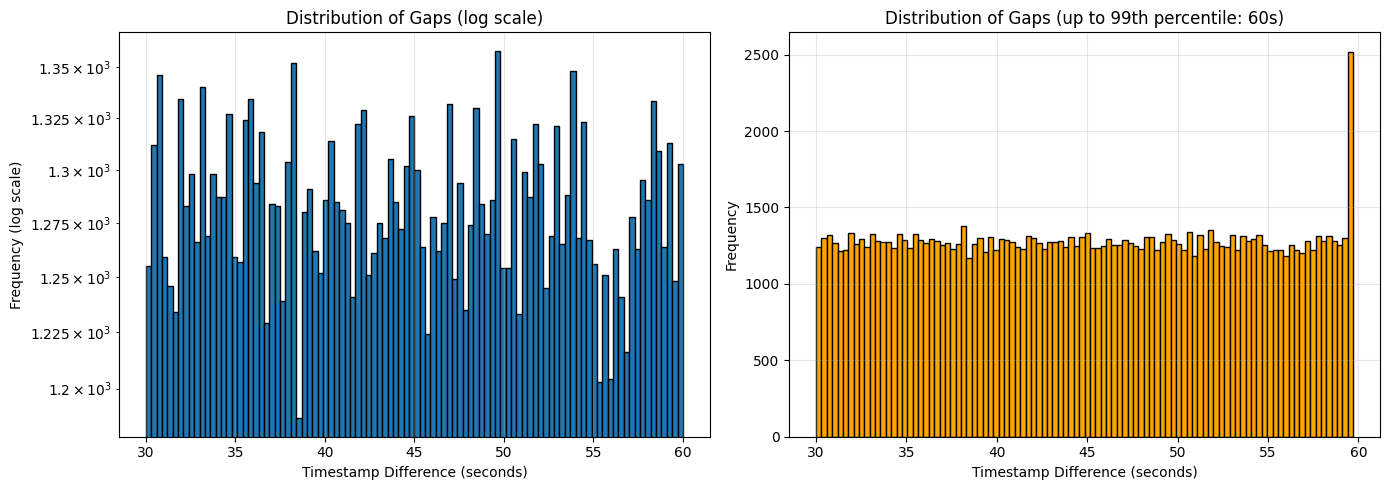

In [12]:
# Create visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Histogram with log scale to handle skewed distribution
axes[0].hist(meteo_station_raw["timestamp_diff"].dropna(), bins=100, edgecolor='black')
axes[0].set_yscale('log')
axes[0].set_xlabel('Timestamp Difference (seconds)')
axes[0].set_ylabel('Frequency (log scale)')
axes[0].set_title('Distribution of Gaps (log scale)')
axes[0].grid(True, alpha=0.3)

# Plot 2: Focus on the main distribution (clip outliers to 99th percentile)
q99 = meteo_station_raw["timestamp_diff"].quantile(0.99)
filtered_diff = meteo_station_raw["timestamp_diff"].dropna().clip(upper=q99)
axes[1].hist(filtered_diff, bins=100, edgecolor='black', color='orange')
axes[1].set_xlabel('Timestamp Difference (seconds)')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'Distribution of Gaps (up to 99th percentile: {q99:.0f}s)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Time series visualization of each numeric feature

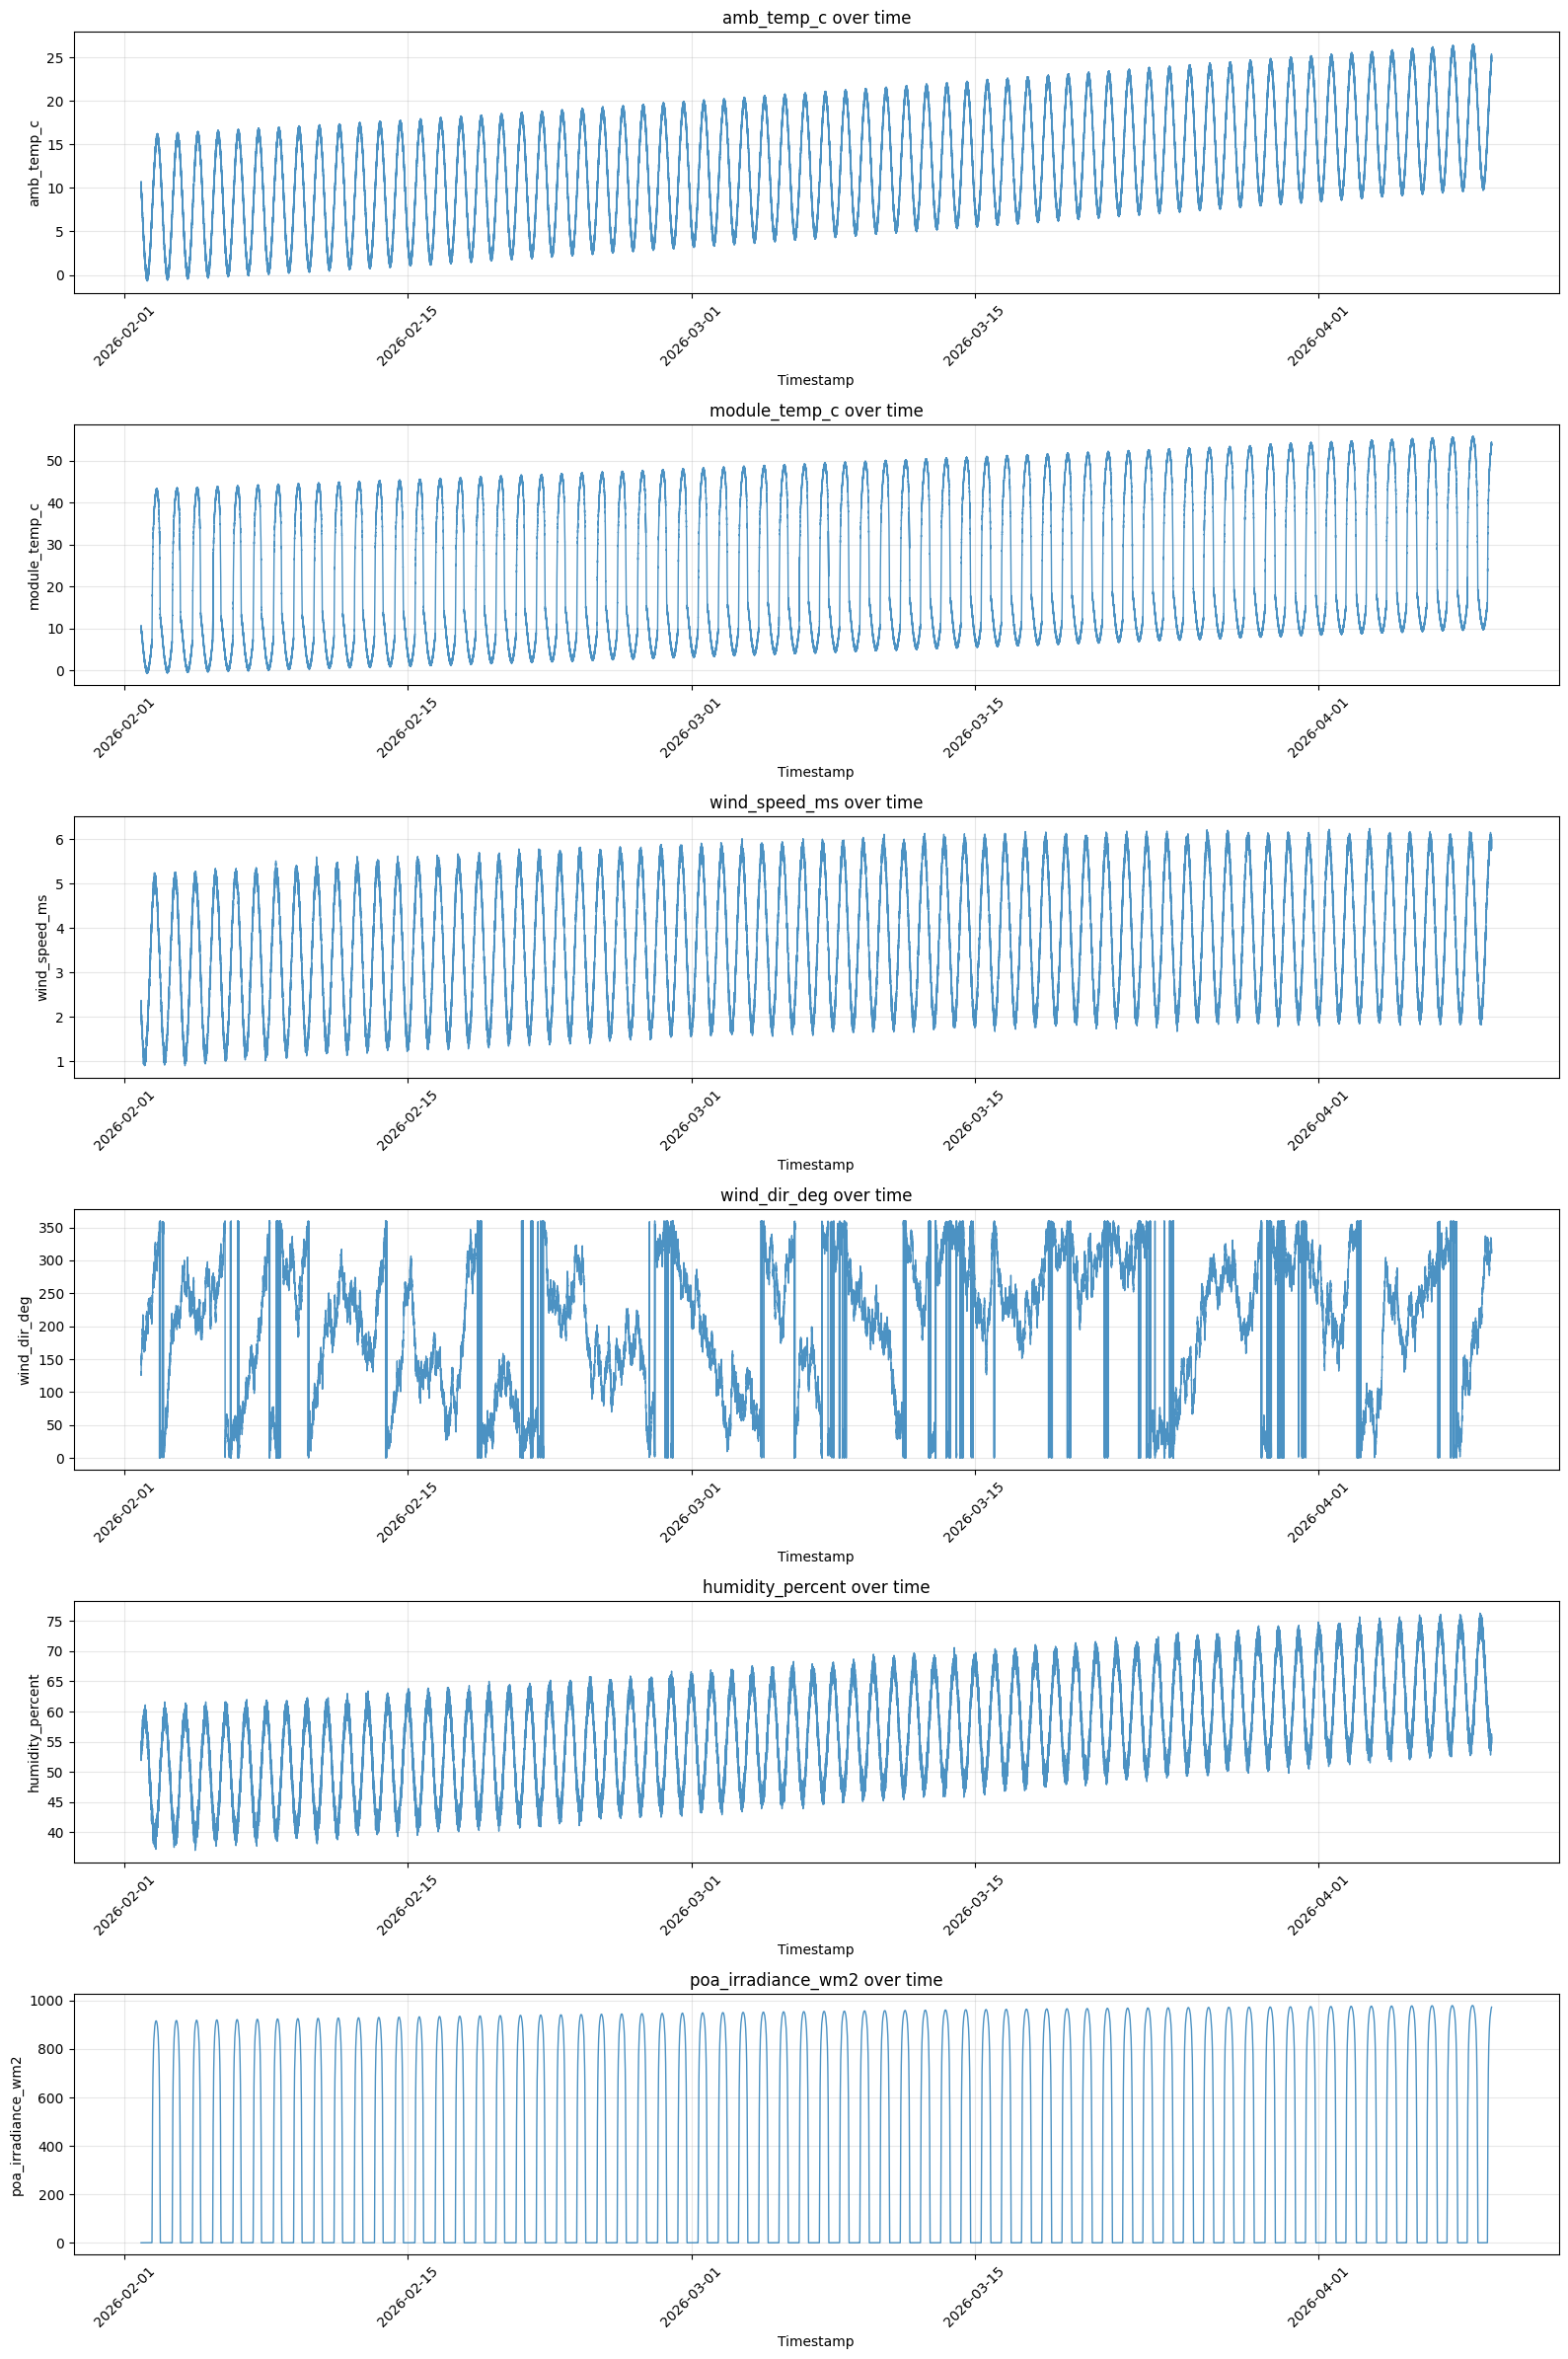

In [13]:
# Get all numeric columns except id and timestamp_diff
numeric_cols = ['amb_temp_c', 'module_temp_c', 'wind_speed_ms', 'wind_dir_deg', 'humidity_percent', 'poa_irradiance_wm2']

# Create subplots for each numeric column
n_cols = 1
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()  # Flatten to 1D array for easier iteration

# Plot each numeric column as a time series
for idx, col in enumerate(numeric_cols):
    ax = axes[idx]
    ax.plot(meteo_station_raw['timestamp'], meteo_station_raw[col], linewidth=1, alpha=0.8)
    ax.set_xlabel('Timestamp')
    ax.set_ylabel(col)
    ax.set_title(f'{col} over time')
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

# Hide unused subplots
for idx in range(len(numeric_cols), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()


## Outlier detection
We will use IQR Method to detect possible outliers in the data.

We will not only use the method, we will check the outliers to consider if they provide information, such as anomalies or errors, or if they only provide wrong information.

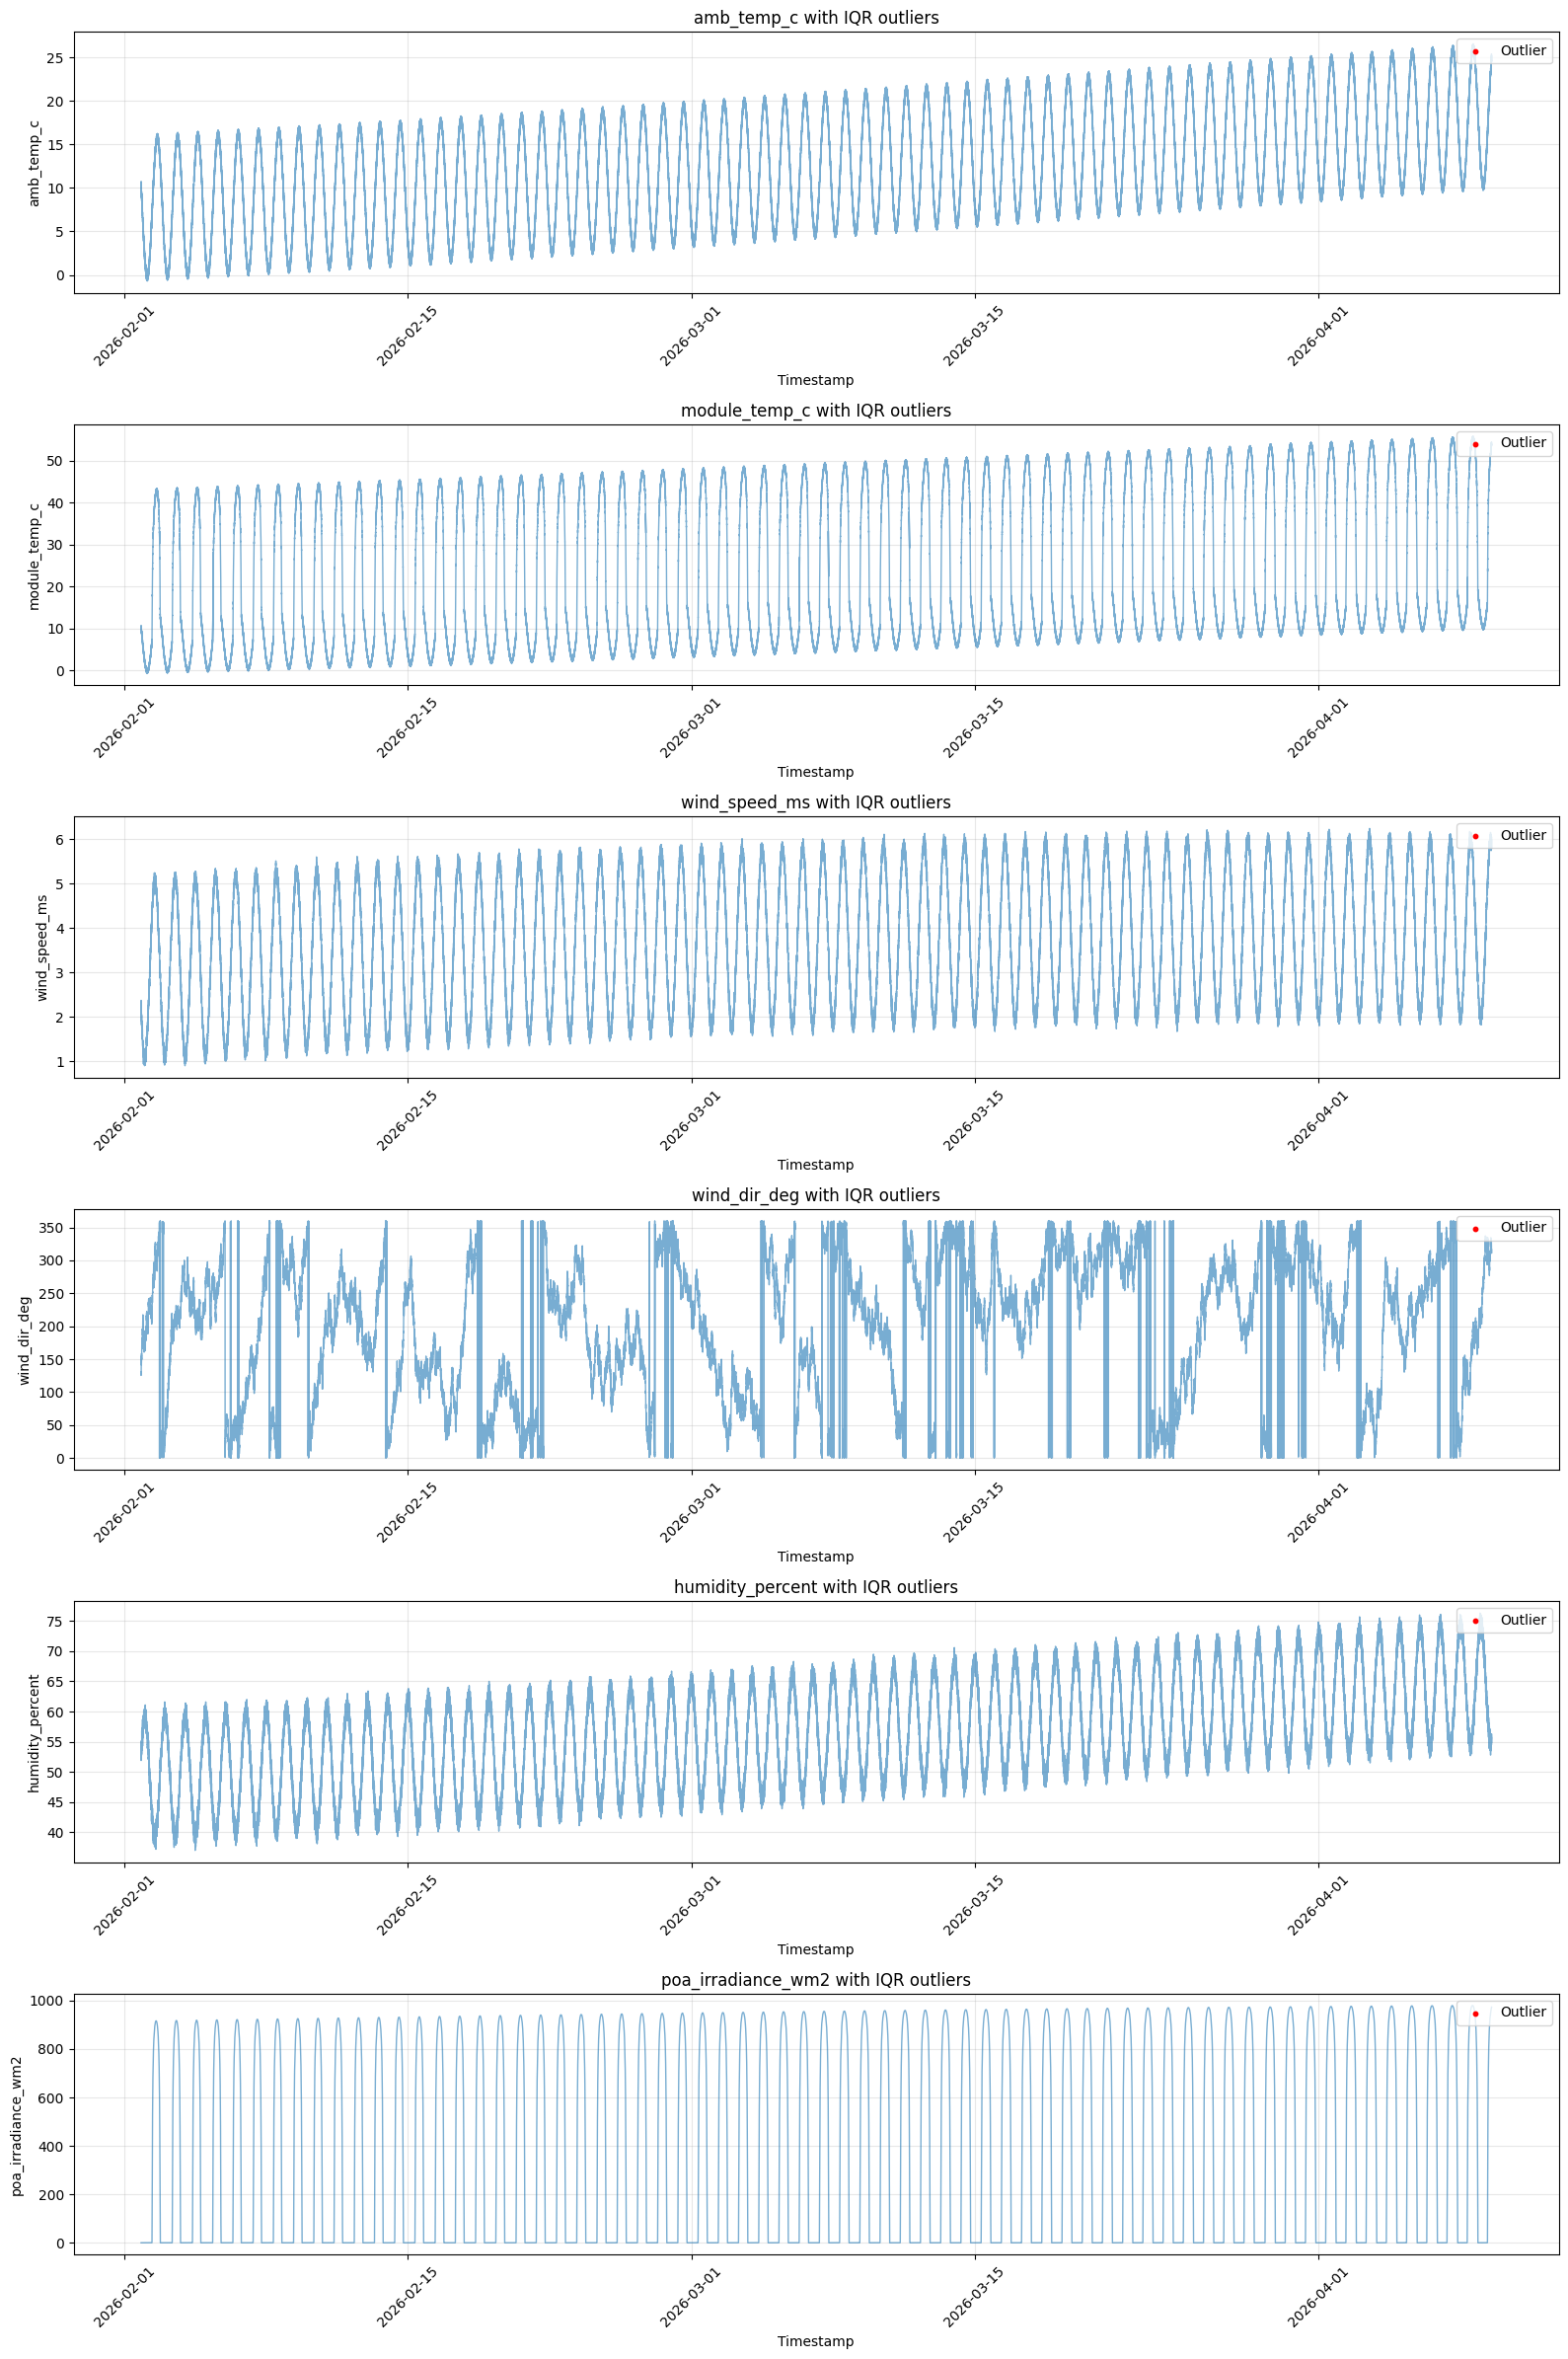

In [14]:
# Compute IQR bounds per column
q1 = meteo_station_raw[numeric_cols].quantile(0.25)
q3 = meteo_station_raw[numeric_cols].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

# Boolean mask of outliers per column
outlier_mask = (meteo_station_raw[numeric_cols] < lower) | (meteo_station_raw[numeric_cols] > upper)

# Plot time series with outliers highlighted in red
n_cols = 1
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    ax = axes[idx]
    ax.plot(meteo_station_raw['timestamp'], meteo_station_raw[col], linewidth=1, alpha=0.6, color='tab:blue')
    outliers = meteo_station_raw[outlier_mask[col]]
    ax.scatter(outliers['timestamp'], outliers[col], color='red', s=10, label='Outlier')
    ax.set_xlabel('Timestamp')
    ax.set_ylabel(col)
    ax.set_title(f'{col} with IQR outliers')
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)
    ax.legend(loc='upper right')

for idx in range(len(numeric_cols), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()